In [1]:
###################################################################################################
#
# Copyright (C) 2025 Analog Devices, Inc. All Rights Reserved.
#
# Analog Devices, Inc. Default Copyright Notice:
#
###################################################################################################

import os
import sys

import numpy as np
import torch

import matplotlib.patches as patches
import matplotlib.pyplot as plt

sys.path.append(os.path.dirname(os.getcwd()))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'models'))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'losses'))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'metrics'))

from datasets import nilm
from losses.nilmmultitargetloss import NILMMultiTargetLoss
from metrics.nilm import CustomNILMRegressionMetrics

### Create test and train sets and visualize sample item/s

In [2]:
device = "cpu"
#CHANGE ME: Change below path to folder that contains or will contain dataset
#           (Data loader will create and use PascalVOC folder ubder this main root folder)
#           Below is an example where a path under Ubuntu root folder ('/'): /data2/ml/ 
#           is used for data files'
data_path = os.path.join('../', 'data')

class Args:
    def __init__(self, act_mode_8bit):
        self.act_mode_8bit = act_mode_8bit
        self.truncate_testset = False

simulate = False
args = Args(act_mode_8bit=simulate)


train_set, test_set = \
    nilm.ukdale_seq2point_get_datasets((data_path, args), load_train=True, load_test=True)
                        

In [3]:
start = 80000
stop = 90000
y_axis = train_set.input_array[start:stop]
x_axis = np.linspace(start, stop, stop-start)

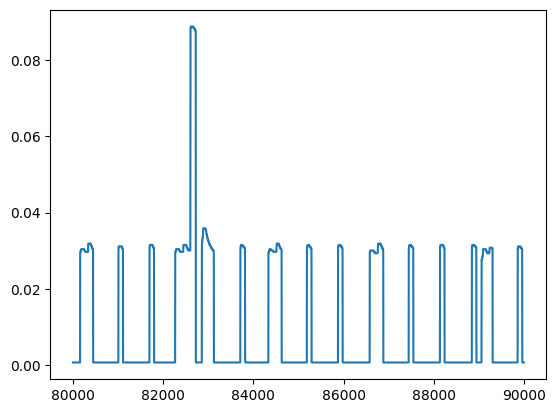

In [4]:
plt.plot(x_axis, y_axis)

In [5]:
selected_idx = 82600

sample_item = test_set[selected_idx]
sample_input = sample_item[0].cpu().detach().numpy()

sample_input

array([[-1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -0.9296875, -0.9296875, -0.9296875, -0.9296875,
        -0.9296875, -0.9296875, -0.9296875, -0.9296875, -0.9296875,
        -0.9296875, -0.9296875, -0.9296875, -0.9296875, -0.9296875,
        -0.9296875, -0.9296875, -0.9296875, -0.9296875, -0.9296875,
        -0.9296875, -0.9296875, -0.9296875, -0.9

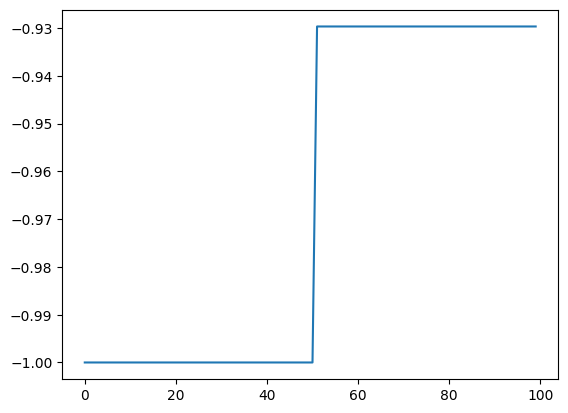

In [7]:
plt.plot(sample_input[0])